In [2]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSeq2SeqLM, pipeline
from tqdm import tqdm

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
def load_jsonl(path):
    data = []
    with open(path) as f:
        for line in f:
            data.append(json.loads(line))
    return data

val_data = load_jsonl("hellaswag_val.300.jsonl")
test_data = load_jsonl("hellaswag_test2.1k.student.jsonl")
train_data = load_jsonl("hellaswag_train.jsonl")

print(f"Val: {len(val_data)}, Test: {len(test_data)}, Train: {len(train_data)}")

Val: 300, Test: 1000, Train: 39905


## Problem 1: Three Prompt Designs (including Chain-of-Thought)

Three sufficiently different prompts; `prompt2_cot` uses Chain-of-Thought.


In [ ]:
def prompt1(ctx, endings):
    opts = "\n".join([f"{chr(65+i)}. {e}" for i, e in enumerate(endings)])
    return (
        f"Context: {ctx}\n\n"
        f"Which of the following best continues the context?\n"
        f"{opts}\n\n"
        f"Answer with a single letter (A, B, C, or D):\n"
    )

def prompt2(ctx, endings):  # Chain of Thought
    opts = "\n".join([f"{chr(65+i)}. {e}" for i, e in enumerate(endings)])
    return (
        f"Context: {ctx}\n\n"
        f"Options:\n{opts}\n\n"
        f"Think step by step about which option most naturally and logically continues the context. "
        f"Consider the subject, action, and setting. "
        f"After reasoning, give your final answer as a single letter (A, B, C, or D).\n"
    )

def prompt3(ctx, endings):
    opts = "\n".join([f"{i+1}. {e}" for i, e in enumerate(endings)])
    return (
        f"The following is a sentence completion task. "
        f"Read the context and pick the most plausible ending.\n\n"
        f"Context: {ctx}\n\n"
        f"{opts}\n\n"
        f"The correct ending number is:"
    )


## Problem 2: Minimal Prompt

Almost no instructions — just the context and options inline.


In [ ]:
def prompt_minimal(ctx, endings):
    opts = " ".join([f"{i+1}) {e}" for i, e in enumerate(endings)])
    return f"{ctx} {opts} Answer:"


## Problem 3: In-Context Learning Prompt

Two labeled examples from the training set shown before the test question.


In [ ]:
ICL_EXAMPLES = (
    "Context: A man is sitting on a roof. he\n"
    "A. is using wrap to wrap a pair of skis.\n"
    "B. is ripping level tiles off.\n"
    "C. is holding a rubik's cube.\n"
    "D. starts pulling up roofing on a roof.\n"
    "Answer: D\n\n"
    "Context: A lady walks to a barbell. She bends down and grabs the pole. the lady\n"
    "A. swings and lands in her arms.\n"
    "B. pulls the barbell forward.\n"
    "C. pulls a rope attached to the barbell.\n"
    "D. stands and lifts the weight over her head.\n"
    "Answer: D\n\n"
)

def prompt_icl(ctx, endings):
    opts = "\n".join([f"{chr(65+i)}. {e}" for i, e in enumerate(endings)])
    return (
        ICL_EXAMPLES +
        f"Context: {ctx}\n"
        f"{opts}\n"
        f"Answer:"
    )

PROMPTS = {
    "prompt1": prompt1,
    "prompt2_cot": prompt2,
    "prompt3": prompt3,
    "prompt_minimal": prompt_minimal,
    "prompt_icl": prompt_icl,
}


## Inference Helpers

In [6]:
def parse_answer(text, prompt_name):
    text = text.strip()
    # look for first occurrence of A/B/C/D or 1/2/3/4
    for ch, idx in [("A",0),("B",1),("C",2),("D",3)]:
        if ch in text[:20]:
            return idx
    for ch, idx in [("1",0),("2",1),("3",2),("4",3)]:
        if ch in text[:20]:
            return idx
    return 0  # fallback


def run_causal_model(model_name, prompt_fn, data, max_new_tokens=50):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=torch.float16, device_map="auto"
    )
    model.eval()

    preds = []
    for item in tqdm(data, desc=model_name):
        text = prompt_fn(item["ctx"], item["endings"])
        inputs = tokenizer(text, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        generated = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        preds.append(parse_answer(generated, prompt_fn.__name__))

    del model
    torch.cuda.empty_cache()
    return preds


def run_seq2seq_model(model_name, prompt_fn, data, max_new_tokens=50):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(
        model_name, torch_dtype=torch.float16, device_map="auto"
    )
    model.eval()

    preds = []
    for item in tqdm(data, desc=model_name):
        text = prompt_fn(item["ctx"], item["endings"])
        inputs = tokenizer(text, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )
        generated = tokenizer.decode(out[0], skip_special_tokens=True)
        preds.append(parse_answer(generated, prompt_fn.__name__))

    del model
    torch.cuda.empty_cache()
    return preds


def run_mistral(prompt_fn, data, max_new_tokens=100):
    model_name = "mistralai/Mistral-7B-Instruct-v0.2"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=torch.float16, device_map="auto"
    )
    model.eval()

    preds = []
    for item in tqdm(data, desc="Mistral"):
        instruction = prompt_fn(item["ctx"], item["endings"])
        messages = [{"role": "user", "content": instruction}]
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(text, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        generated = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        preds.append(parse_answer(generated, prompt_fn.__name__))

    del model
    torch.cuda.empty_cache()
    return preds


def accuracy(preds, data):
    labels = [item["label"] for item in data]
    correct = sum(p == l for p, l in zip(preds, labels))
    return correct / len(labels)

## Problem 4

Written reflection is in `hw4_writeup.pdf`.

## Problem 5: Evaluate all prompts × all models

In [6]:
results = {}  # results[model_name][prompt_name] = accuracy

# --- GPT2 ---
results["GPT2"] = {}
for pname, pfn in PROMPTS.items():
    preds = run_causal_model("openai-community/gpt2", pfn, val_data)
    results["GPT2"][pname] = accuracy(preds, val_data)
    print(f"GPT2 | {pname}: {results['GPT2'][pname]:.3f}")

openai-community/gpt2: 100%|██████████| 300/300 [01:37<00:00,  3.07it/s]


GPT2 | prompt1: 0.270


openai-community/gpt2: 100%|██████████| 300/300 [01:39<00:00,  3.00it/s]


GPT2 | prompt2_cot: 0.270


openai-community/gpt2: 100%|██████████| 300/300 [01:39<00:00,  3.00it/s]


GPT2 | prompt3: 0.270


openai-community/gpt2: 100%|██████████| 300/300 [01:38<00:00,  3.06it/s]


GPT2 | prompt_minimal: 0.270


openai-community/gpt2: 100%|██████████| 300/300 [01:38<00:00,  3.03it/s]

GPT2 | prompt_icl: 0.273


In [7]:
# --- Gemma-2b ---
results["Gemma-2b"] = {}
for pname, pfn in PROMPTS.items():
    preds = run_causal_model("google/gemma-2b", pfn, val_data)
    results["Gemma-2b"][pname] = accuracy(preds, val_data)
    print(f"Gemma-2b | {pname}: {results['Gemma-2b'][pname]:.3f}")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model-00001-of-00002.safetensors:  70%|######9   | 3.44G/4.95G [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

`config.hidden_act` is ignored, you should use `config.hidden_activation` instead.
Gemma's activation function will be set to `gelu_pytorch_tanh`. Please, use
`config.hidden_activation` if you want to override this behaviour.
See https://github.com/huggingface/transformers/pull/29402 for more details.


...

google/gemma-2b: 100%|██████████| 300/300 [02:48<00:00,  1.78it/s]


Gemma-2b | prompt_minimal: 0.280


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

google/gemma-2b: 100%|██████████| 300/300 [05:17<00:00,  1.06s/it]

Gemma-2b | prompt_icl: 0.273


In [8]:
# --- flan-t5-large ---
results["flan-t5-large"] = {}
for pname, pfn in PROMPTS.items():
    preds = run_seq2seq_model("google/flan-t5-large", pfn, val_data)
    results["flan-t5-large"][pname] = accuracy(preds, val_data)
    print(f"flan-t5-large | {pname}: {results['flan-t5-large'][pname]:.3f}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

flan-t5-large | prompt3: 0.597


google/flan-t5-large: 100%|██████████| 300/300 [01:46<00:00,  2.82it/s]


flan-t5-large | prompt_minimal: 0.427


google/flan-t5-large: 100%|██████████| 300/300 [00:25<00:00, 11.81it/s]


flan-t5-large | prompt_icl: 0.643


In [9]:
# --- OPT-2.7b ---
results["OPT-2.7b"] = {}
for pname, pfn in PROMPTS.items():
    preds = run_causal_model("facebook/opt-2.7b", pfn, val_data)
    results["OPT-2.7b"][pname] = accuracy(preds, val_data)
    print(f"OPT-2.7b | {pname}: {results['OPT-2.7b'][pname]:.3f}")

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

...

OPT-2.7b | prompt3: 0.270


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
facebook/opt-2.7b: 100%|██████████| 300/300 [03:18<00:00,  1.51it/s]


OPT-2.7b | prompt_minimal: 0.273


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
facebook/opt-2.7b: 100%|██████████| 300/300 [03:34<00:00,  1.40it/s]


OPT-2.7b | prompt_icl: 0.293


In [14]:
# --- Mistral-7B-Instruct ---
results["Mistral-7B"] = {}
for pname, pfn in PROMPTS.items():
    preds = run_mistral(pfn, val_data)
    results["Mistral-7B"][pname] = accuracy(preds, val_data)
    print(f"Mistral-7B | {pname}: {results['Mistral-7B'][pname]:.3f}")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Mistral: 100%|██████████| 300/300 [09:32<00:00,  1.91s/it]


Mistral-7B | prompt1: 0.587


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Mistral: 100%|██████████| 300/300 [15:23<00:00,  3.08s/it]


...

Mistral: 100%|██████████| 300/300 [15:54<00:00,  3.18s/it]


Mistral-7B | prompt_minimal: 0.287


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Mistral: 100%|██████████| 300/300 [12:18<00:00,  2.46s/it]


Mistral-7B | prompt_icl: 0.543


In [15]:
# save results in case kernel dies
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("saved")

saved


## Problem 5: Plots

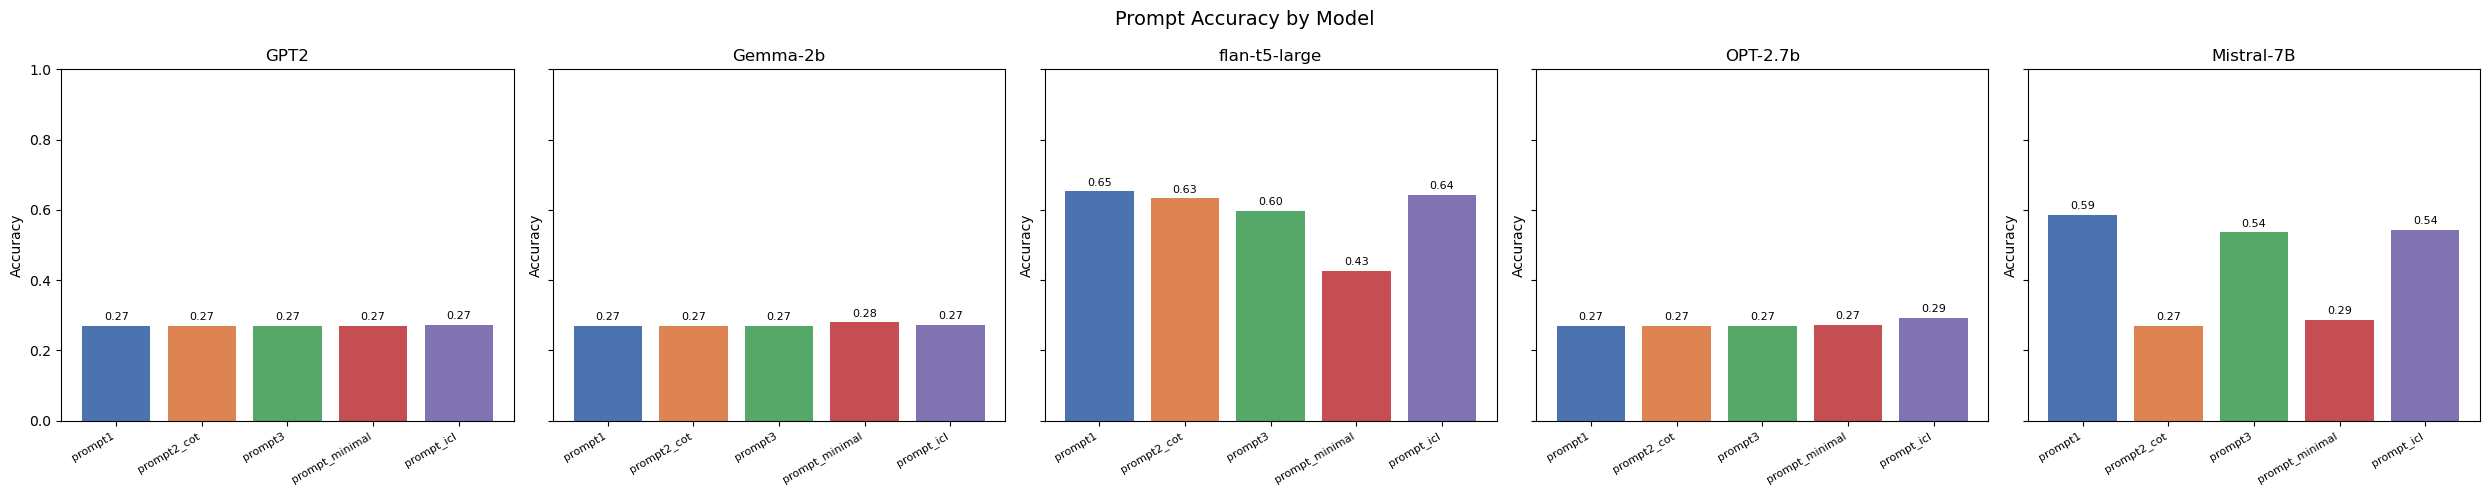

In [16]:
# reload if needed
# with open("results.json") as f:
#     results = json.load(f)

prompt_names = list(PROMPTS.keys())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5), sharey=True)

for ax, (model_name, scores) in zip(axes, results.items()):
    accs = [scores[p] for p in prompt_names]
    bars = ax.bar(prompt_names, accs, color=colors)
    ax.set_title(model_name)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_xticks(range(len(prompt_names)))
    ax.set_xticklabels(prompt_names, rotation=30, ha="right", fontsize=8)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f"{acc:.2f}",
                ha="center", va="bottom", fontsize=8)

plt.suptitle("Prompt Accuracy by Model", fontsize=14)
plt.tight_layout()
plt.savefig("results_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Problem 6: Generate test predictions with best prompt+model

In [17]:
# find best combo
best_model, best_prompt, best_acc = None, None, 0
for model_name, scores in results.items():
    for pname, acc in scores.items():
        if acc > best_acc:
            best_acc = acc
            best_model = model_name
            best_prompt = pname

print(f"Best: {best_model} + {best_prompt} -> {best_acc:.3f}")

Best: flan-t5-large + prompt1 -> 0.653


In [18]:
MODEL_FN_MAP = {
    "GPT2": ("openai-community/gpt2", "causal"),
    "Gemma-2b": ("google/gemma-2b", "causal"),
    "flan-t5-large": ("google/flan-t5-large", "seq2seq"),
    "OPT-2.7b": ("facebook/opt-2.7b", "causal"),
    "Mistral-7B": (None, "mistral"),
}

pfn = PROMPTS[best_prompt]
model_id, mtype = MODEL_FN_MAP[best_model]

if mtype == "causal":
    test_preds = run_causal_model(model_id, pfn, test_data)
elif mtype == "seq2seq":
    test_preds = run_seq2seq_model(model_id, pfn, test_data)
else:
    test_preds = run_mistral(pfn, test_data)

print(f"Generated {len(test_preds)} predictions")

google/flan-t5-large: 100%|██████████| 1000/1000 [01:25<00:00, 11.72it/s]


Generated 1000 predictions


In [19]:
submission = [{"ind": item["ind"], "label": pred} for item, pred in zip(test_data, test_preds)]
with open("submission.json", "w") as f:
    json.dump(submission, f)
print("submission.json saved")

submission.json saved


## Problem 7

Written reflection is in `hw4_writeup.pdf`.

## Fix: re-run Mistral + CoT with improved answer parsing

The original `parse_answer` only scanned the first 20 characters, which misses the final answer in CoT responses where the model reasons at length before answering. The fixed version searches the full output and prioritizes the last occurring letter.

In [7]:
def parse_answer_v2(text):
    text = text.strip()
    # search entire output; take the last occurrence of a valid answer token
    last = {}
    for ch, idx in [('A', 0), ('B', 1), ('C', 2), ('D', 3)]:
        pos = text.rfind(ch)
        if pos != -1:
            last[pos] = idx
    if last:
        return last[max(last)]
    for ch, idx in [('1', 0), ('2', 1), ('3', 2), ('4', 3)]:
        pos = text.rfind(ch)
        if pos != -1:
            last[pos] = idx
    if last:
        return last[max(last)]
    return 0


def run_mistral_v2(prompt_fn, data, max_new_tokens=100):
    model_name = 'mistralai/Mistral-7B-Instruct-v0.2'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=torch.float16, device_map='auto'
    )
    model.eval()

    preds = []
    for item in tqdm(data, desc='Mistral-v2'):
        instruction = prompt_fn(item['ctx'], item['endings'])
        messages = [{'role': 'user', 'content': instruction}]
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(text, return_tensors='pt').to(device)
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        generated = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        preds.append(parse_answer_v2(generated))

    del model
    torch.cuda.empty_cache()
    return preds


# re-run only Mistral + CoT
with open('results.json') as f:
    results = json.load(f)

preds_cot = run_mistral_v2(prompt2, val_data)
results['Mistral-7B']['prompt2_cot'] = accuracy(preds_cot, val_data)
print(f"Mistral-7B | prompt2_cot (fixed): {results['Mistral-7B']['prompt2_cot']:.3f}")

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('results.json updated')

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Mistral-v2: 100%|██████████| 300/300 [15:44<00:00,  3.15s/it]


Mistral-7B | prompt2_cot (fixed): 0.433
results.json updated


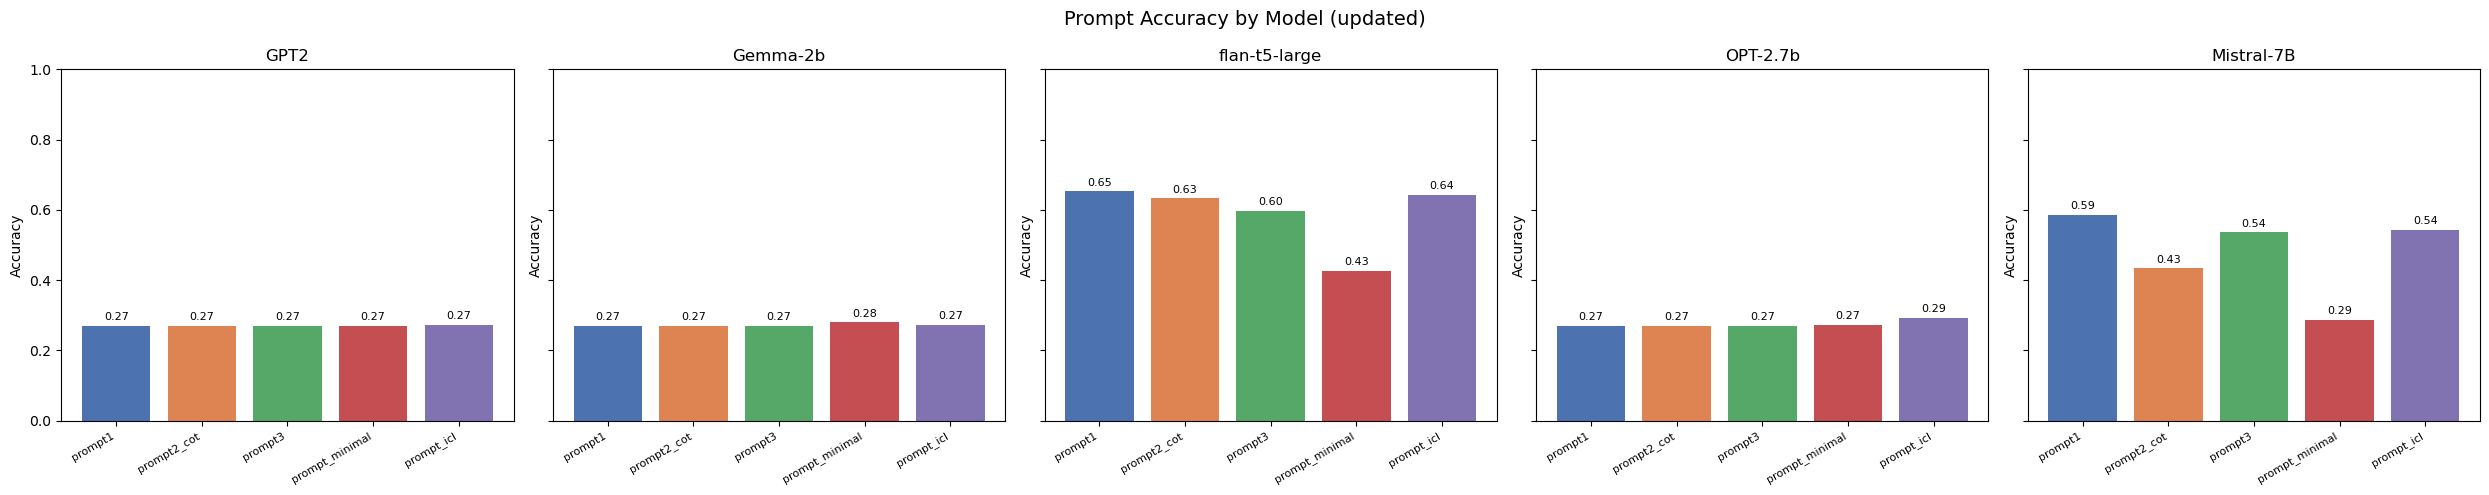

In [8]:
# re-plot with updated results
prompt_names = list(PROMPTS.keys())
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5), sharey=True)

for ax, (model_name, scores) in zip(axes, results.items()):
    accs = [scores[p] for p in prompt_names]
    bars = ax.bar(prompt_names, accs, color=colors)
    ax.set_title(model_name)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Accuracy')
    ax.set_xticks(range(len(prompt_names)))
    ax.set_xticklabels(prompt_names, rotation=30, ha='right', fontsize=8)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.2f}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Prompt Accuracy by Model (updated)', fontsize=14)
plt.tight_layout()
plt.savefig('results_plot_updated.png', dpi=150, bbox_inches='tight')
plt.show()

## Problem 5: Trend Analysis

The results split cleanly along IFT vs.\ non-IFT lines. GPT2, OPT-2.7b, and Gemma-2b all land at or just above chance (0.27--0.28) regardless of prompt, confirming that zero-shot classification via generation requires a model that has been instruction fine-tuned. No amount of prompt engineering rescued these models on this task.

Among the IFT models, flan-t5-large was the strongest overall, reaching 0.653 with prompt1 and 0.643 with the ICL prompt. Mistral-7B was competitive on structured prompts (0.587, 0.543, 0.537 for prompt1, prompt\_icl, prompt3 respectively) but more sensitive to prompt format---the minimal prompt collapsed it to 0.287, near chance, while flan-t5 degraded more gracefully to 0.427. Chain-of-thought helped flan-t5 only slightly less than prompt1 (0.633 vs. 0.653), whereas Mistral CoT scored 0.433---lower than simpler formats---because the longer reasoning chain makes extracting the final answer less reliable.